In [1]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib

from alter_surf.hamiltonian_DLKK import H_DLKK_3D_MF, Spin_operator, Sublattice_operator, points_BZ, Econst_DLKK_3D_MF
from alter_surf.mean_field import hartree_fock



In [ ]:
Hparam0 = dict(len_z=10,delta=0.8, tp=0.5, tz=1, U=5, filling=0.5+1e-2, PBC= False)
#Hparam0 = dict(len_z=2,delta=0., tp=-0.16, tz=0., U=10, filling=0.5, PBC= True)
Lq = 40
initial_parameters = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/4,
                          initial_mF =np.ones(Hparam0['len_z']) * 0,
                          initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
MF_parameters = dict(n_steps=60, Lq=Lq, tol_mdiff=1e-4,mixing_proportion=0.1,adjust_learning_rate=False)

mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_parameters, **MF_parameters)

Hparam = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1],mu=fermi_energys[-1])



Avg:-0.00, Stag. avg:0.65, diff: 0.000022:  50%|█████     | 30/60 [00:17<00:17,  1.75it/s]


Checking the convergence of the MF simualtion 

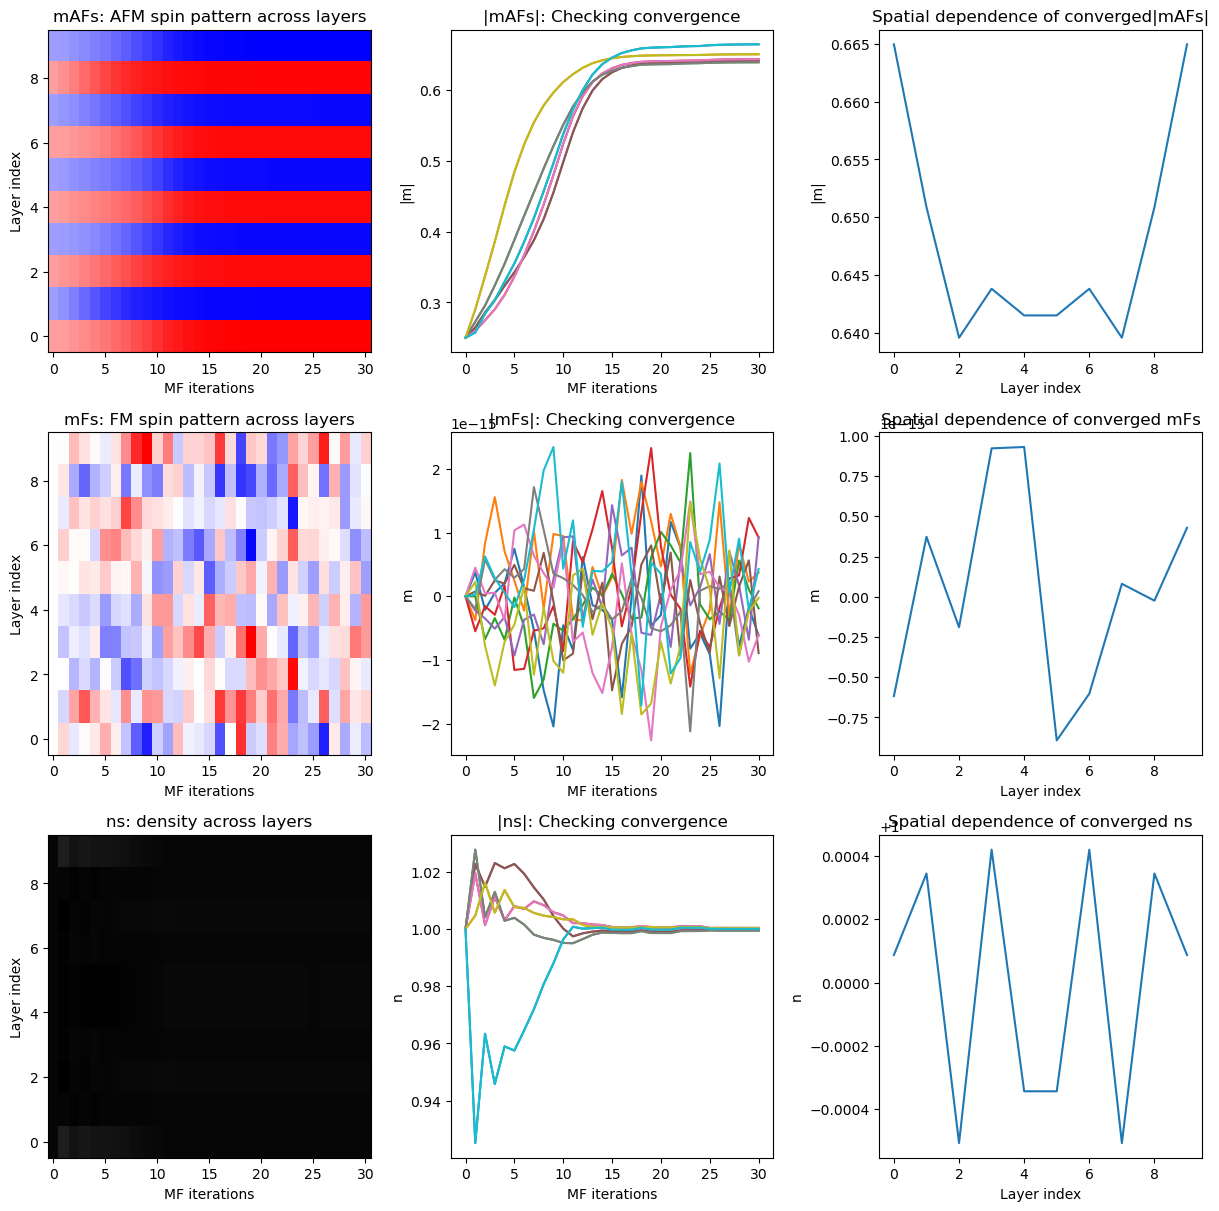

In [98]:
fig, axs = plt.subplots(3,3, figsize=(12,12), constrained_layout=True)

#plot the AF magnatization 
axs[0,0].set_title('mAFs: AFM spin pattern across layers')
axs[0,0].set_xlabel('MF iterations')
axs[0,0].set_ylabel('Layer index')
axs[0,0].imshow(mAFs.T, aspect='auto', cmap='bwr',origin='lower', vmin=-mAFs.max(), vmax=mAFs.max())

axs[0,1].set_title('|mAFs|: Checking convergence')
axs[0,1].set_xlabel('MF iterations')
axs[0,1].set_ylabel('|m|')
axs[0,1].plot(np.abs(mAFs))

axs[0,2].set_title('Spatial dependence of converged|mAFs|')
axs[0,2].set_xlabel('Layer index')
axs[0,2].set_ylabel('|m|')
axs[0,2].plot(np.abs(mAFs[-1]))

#plot the F magnatization 
axs[1,0].set_title('mFs: FM spin pattern across layers')
axs[1,0].set_xlabel('MF iterations')
axs[1,0].set_ylabel('Layer index')
axs[1,0].imshow(mFs.T, aspect='auto', cmap='bwr',origin='lower', vmin=-mFs.max(), vmax=mFs.max())

axs[1,1].set_title('|mFs|: Checking convergence')
axs[1,1].set_xlabel('MF iterations')
axs[1,1].set_ylabel('m')
axs[1,1].plot(mFs)

axs[1,2].set_title('Spatial dependence of converged mFs')
axs[1,2].set_xlabel('Layer index')
axs[1,2].set_ylabel('m')
axs[1,2].plot(mFs[-1])

#plot the density 
axs[2,0].set_title('ns: density across layers')
axs[2,0].set_xlabel('MF iterations')
axs[2,0].set_ylabel('Layer index')
axs[2,0].imshow(ns.T, aspect='auto', cmap='Greys',origin='lower', vmin=0, vmax=ns.max())

axs[2,1].set_title('|ns|: Checking convergence')
axs[2,1].set_xlabel('MF iterations')
axs[2,1].set_ylabel('n')
axs[2,1].plot(ns)

axs[2,2].set_title('Spatial dependence of converged ns')
axs[2,2].set_xlabel('Layer index')
axs[2,2].set_ylabel('n')
axs[2,2].plot(ns[-1])




Now we need to check that it is acutally the lowest state in (free) energy. (Free in brackets because we are only interested in T=0) 

1) Compute the paramagnetic/ non-magnetic (PM) self consistent solution 

  0%|          | 0/60 [00:00<?, ?it/s]

Fixed chemical potential:  1.3109842937596614


Avg:0.00, Stag. avg:-0.00, diff: 0.000126: 100%|██████████| 60/60 [00:32<00:00,  1.84it/s]


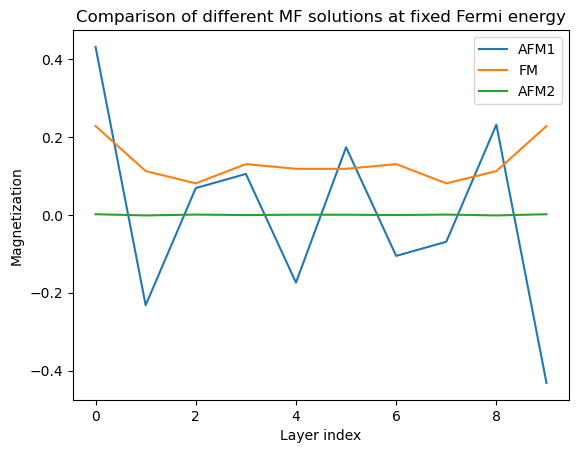

In [99]:
#we fix the chemical potential for the state of interest:
Hparam0['mu'] = Hparam['mu']
print('Fixed chemical potential: ', Hparam0['mu'])

initial_param_NM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AFM = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/4,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_FM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.ones(Hparam0['len_z'])/4,
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_FM2 = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =(-1)**np.arange(Hparam0['len_z'])/4,
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AFM2= dict(initial_mAF=(1)**np.arange(Hparam0['len_z'])/100,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)

#solve MF equations at fixed Fermi energy
mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_param_NM, **MF_parameters,fixed_Fermi_energy=True)
if not np.allclose(fermi_energys,Hparam0['mu']):
        print(fermi_energys-Hparam0['mu'])
        raise ValueError("Fermi energy is not fixed as you requested.")
Hparam_NM = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])

mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_param_AFM, **MF_parameters,fixed_Fermi_energy=True)
if not np.allclose(fermi_energys,Hparam0['mu']):
        raise ValueError("Fermi energy is not fixed as you requested.")
Hparam_AFM1 = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])

mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_param_FM, **MF_parameters,fixed_Fermi_energy=True)
if not np.allclose(fermi_energys,Hparam0['mu']):
        raise ValueError("Fermi energy is not fixed as you requested.")
Hparam_FM = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])

mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_param_FM2, **MF_parameters,fixed_Fermi_energy=True)
if not np.allclose(fermi_energys,Hparam0['mu']):
        raise ValueError("Fermi energy is not fixed as you requested.")
Hparam_FM2= dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])

mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_param_AFM2, **MF_parameters,fixed_Fermi_energy=True)
if not np.allclose(fermi_energys,Hparam0['mu']):
        raise ValueError("Fermi energy is not fixed as you requested.")
Hparam_AFM2 = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])


plt.plot(Hparam_AFM1['mAF'],label='AFM1')
plt.plot(Hparam_FM['mF'],label='FM')
plt.plot(Hparam_AFM2['mAF'],label='AFM2')
plt.xlabel('Layer index')
plt.ylabel('Magnetization')
plt.title('Comparison of different MF solutions at fixed Fermi energy')
plt.legend()


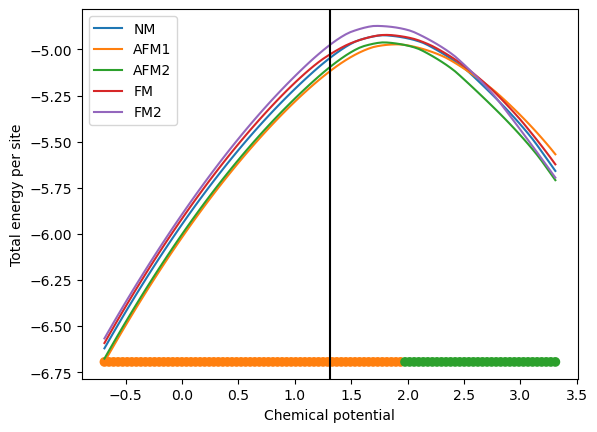

In [100]:
from blochK.observable import eigs_H, exp_value_O,conductivity
from blochK.methods_basic import sample_reducedBZ

Lq = 100
dmus = np.linspace(-2,2,100) #which mus to scan



def unvectorized_total_energy_dmus(dmu,Hparam,es):
    """total energy per unit cell (sqrt(2) x sqrt(2) x 1) as a function of mu + dmu"""
    total_energy = np.sum(es[es<dmu]-dmu)/(Lq**2)/Hparam['len_z'] + Econst_DLKK_3D_MF(**Hparam)
    #print(np.array([np.sum(es[es<dmu]-dmu)/(Lq**2) for dmu in dmus]), Econst_DLKK_3D_MF(**Hparam))
    return total_energy

total_energy_dmus = np.vectorize(unvectorized_total_energy_dmus,excluded=(1,2))

def total_energy(dmus,Hparam,Lq=50):
    ks = sample_reducedBZ(Lq)
    es,_ = eigs_H(*ks, H_DLKK_3D_MF, Hparam)
    e_tots = total_energy_dmus(dmus,Hparam,es)

    return e_tots + 2*(Hparam['mu'] + dmus)


# total_energy([0],Hparam_NM,Lq=Lq)
# total_energy([0],Hparam_AFM,Lq=Lq)
# total_energy([0],Hparam_FM,Lq=Lq)


e_tot_NM  = total_energy(dmus,Hparam_NM,Lq=Lq)
e_tot_AFM1= total_energy(dmus,Hparam_AFM1,Lq=Lq)
e_tot_AFM2= total_energy(dmus,Hparam_AFM2,Lq=Lq)
e_tot_FM  = total_energy(dmus,Hparam_FM,Lq=Lq)
e_tot_FM2 = total_energy(dmus,Hparam_FM2,Lq=Lq)


mus = Hparam['mu']+dmus

plt.plot(mus,e_tot_NM,label='NM')
plt.plot(mus,e_tot_AFM1,label='AFM1')
plt.plot(mus,e_tot_AFM2,label='AFM2')
plt.plot(mus,e_tot_FM,label='FM')
plt.plot(mus,e_tot_FM2,label='FM2')
plt.axvline(Hparam['mu'],color='k')
plt.xlabel('Chemical potential')
plt.ylabel('Total energy per site')
plt.legend()

e_tots = np.array([e_tot_NM,e_tot_AFM1,e_tot_AFM2,e_tot_FM,e_tot_FM2])
iphase = np.argmin(e_tots,axis=0)

colors = np.array(['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9'])
plt.scatter(mus,np.ones_like(dmus)*e_tots.min(),color=colors[iphase])



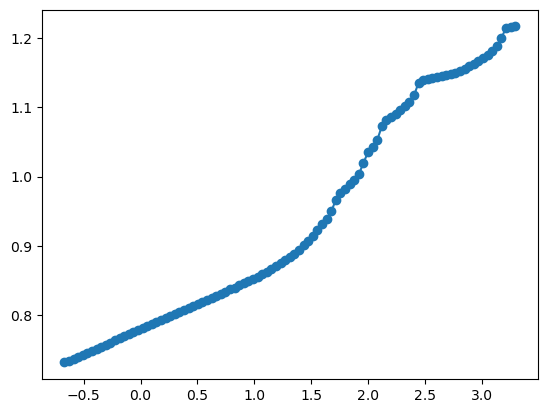

In [101]:
e_min = e_tots.min(axis=0)

xs = (mus[1:]+mus[:-1])/2
rhos = 1-(e_min[1:]-e_min[:-1])/(mus[1:]-mus[:-1])/4


plt.plot(xs,rhos,'-o')

In [7]:

Lq = 40
ks = sample_reducedBZ(Lq)
es, psi = eigs_H(*ks, H_DLKK_3D_MF, Hparam)
es_PM, psi_PM = eigs_H(*ks, H_DLKK_3D_MF, Hparam_PM)


dmus = np.linspace(-2.,2,50)

e_tots  = []; e_tots_PM  = []

for dmu in dmus:
    total_energy = np.sum(es[es<mu+dmu])/(Lq**2) + Econst_DLKK_3D_MF(**Hparam)
    total_energy_UC = total_energy/Hparam['len_z']
    e_tots.append(total_energy_UC)

    total_energy_PM = np.sum(es_PM[es_PM<mu_PM+dmu])/(Lq**2) + Econst_DLKK_3D_MF(**Hparam_PM)
    total_energy_UC_PM = total_energy_PM/Hparam_PM['len_z']
    e_tots_PM.append(total_energy_UC_PM)

mu_min = mu + dmus[np.argmin(e_tots)]
mu_min_PM = mu_PM + dmus[np.argmin(e_tots_PM)]

fig,axs = plt.subplots(1,2, figsize=(10,4))
axs[0].set_xlabel('Chemical potential mu')
axs[0].set_ylabel('Total energy per unit cell')
axs[0].plot(dmus + mu, e_tots)
axs[0].axvline(mu, color='C0', linestyle='--', label='AFM mu MF')
axs[0].plot(dmus + mu_PM, e_tots_PM)
axs[0].axvline(mu_PM, color='C1', linestyle='--', label='PM mu MF')
axs[0].axvline(mu_min, color='C0', linestyle=':', label='AFM mu min')
axs[0].axvline(mu_min_PM, color='C1', linestyle=':', label='PM mu min')
axs[0].legend()

axs[1].set_xlabel('Chemical potential mu')
axs[1].set_ylabel('Total energy per unit cell')
axs[1].plot(dmus + mu, e_tots)
axs[1].axvline(mu, color='C0', linestyle='--', label='AFM mu MF')
axs[1].axvline(mu_min, color='C0', linestyle=':', label='AFM mu min')
axs[1].legend()

print('PM: ')
print(f"\t initial mu: {mu_PM:.4f} ")
print(f"\t initial filling: {np.sum(es_PM<0)/(Lq**2*4*Hparam_PM['len_z']): .6f} ")
print(f"\t mu min: {mu_min_PM:.4f} ")
print(f"\t filling at mu min: {np.sum(es_PM<(mu_min_PM-mu_PM))/(Lq**2*4*Hparam_PM['len_z']): .6f} ")

print('AFM: ')
print(f"\t initial mu: {mu:.4f} ")
print(f"\t initial filling: {np.sum(es<0)/(Lq**2*4*Hparam['len_z']): .6f} ")
print(f"\t mu min: {mu_min:.4f} ")
print(f"\t filling at mu min: {np.sum(es<(mu_min-mu))/(Lq**2*4*Hparam['len_z']): .6f} ")


NameError: name 'Hparam_PM' is not defined

In [47]:

fermi_occupation = es<mu #boolean array, true if state is occupied
local_densities = np.einsum('nkqa,nkq->a',np.abs(psi)**2,fermi_occupation)/Lq**2 #sum up bands, momenta, momenta

print('Local densities (AFM): ', local_densities)

len_z = 100000000
x = np.random.rand(2,4*len_z)







Local densities (AFM):  [0.74031771 0.25968229 0.25968229 0.74031771 0.25968229 0.74031771
 0.74031771 0.25968229]


In [59]:
param = dict()
(param['mAF'], param['mF'], param['ns']) = np.random.rand(3,4)

In [49]:

np.einsum('xz,x->z',x,np.array([1,-1]))

array([-0.14720827, -0.51262082, -0.93867132, ..., -0.00199484,
       -0.81649055,  0.96640711])

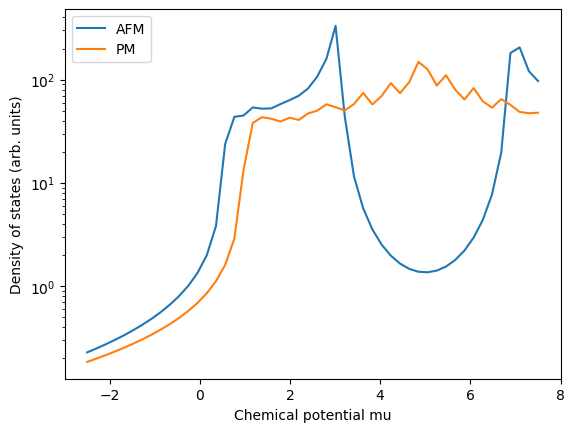

In [8]:
Gamma = 5e-2
doss  = []; doss_PM  = []

for dmu in dmus:
    dos = np.sum(1/((es - dmu)**2 + Gamma**2))/(Lq**2)
    doss.append(dos)

    dos_PM = np.sum(1/((es_PM - dmu)**2 + Gamma**2))/(Lq**2)
    doss_PM.append(dos_PM)

plt.plot(dmus + mu, doss, label='AFM')
plt.plot(dmus + mu_PM, doss_PM, label='PM')
plt.xlabel('Chemical potential mu')
plt.ylabel('Density of states (arb. units)')
plt.yscale('log')
plt.legend()

In [166]:
dmu = 0.2
np.sum(es[es<+dmu])/Lq**2/Hparam['len_z']

-8.027154164477077

[ 0.66495022 -0.65086764  0.63957523 -0.6438085   0.64150472 -0.64150472
  0.6438085  -0.63957523  0.65086764 -0.66495022] 1.3109842937596614


/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:65: UserWarning: No contour levels were found within the data range.
  FS0 = ax.contour(xs,ys,es[iband],[0],alpha=0)


0.49968


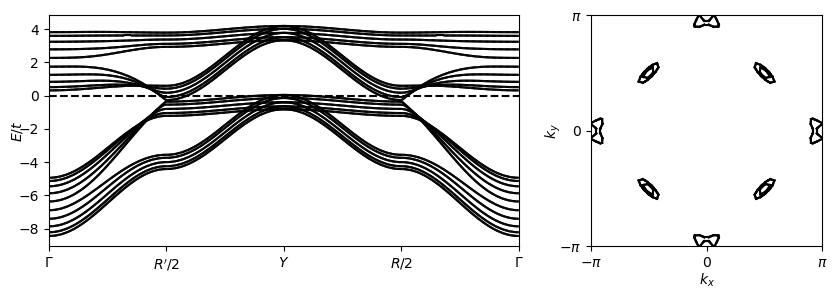

In [102]:
from blochK.plotting import plot_FS, plot_bandstruc

param = Hparam.copy()

print(param['mAF'],param['mu'])

labels = ["R'",'\Gamma','R',"X",'\Gamma']
labels = ['\Gamma',"R'/2","Y","R/2",'\Gamma']
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]

coloring_operator = np.kron(np.ones(param['len_z']), Spin_operator)

cmap = 'bwr'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H_DLKK_3D_MF,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK_3D_MF,param=param,coloring_operator=coloring_operator,cmap=cmap,Lq=50,print_filling=True)


In [103]:
Lq = 50 #number of k-points in each direction
Hamiltonian_fct = H_DLKK_3D_MF


# Define the parameters for the Hamiltonian
param = Hparam
# Define the k-point grid
kxs = np.linspace(-pi,pi,Lq)
kys = np.linspace(-pi,pi,Lq)
xs,ys = np.meshgrid(kxs,kys)
ks = np.moveaxis([xs,ys],0,-1)
#Diagonalize Hamiltonian
es,psis = eigs_H(xs,ys,Hamiltonian_fct,param)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=vmin,vmax=vmax)
    return im


def projector2layer(layer,len_z=2):
    """Projector operator onto specific layer."""
    proj = np.zeros(len_z)
    proj[layer] = 1
    return proj




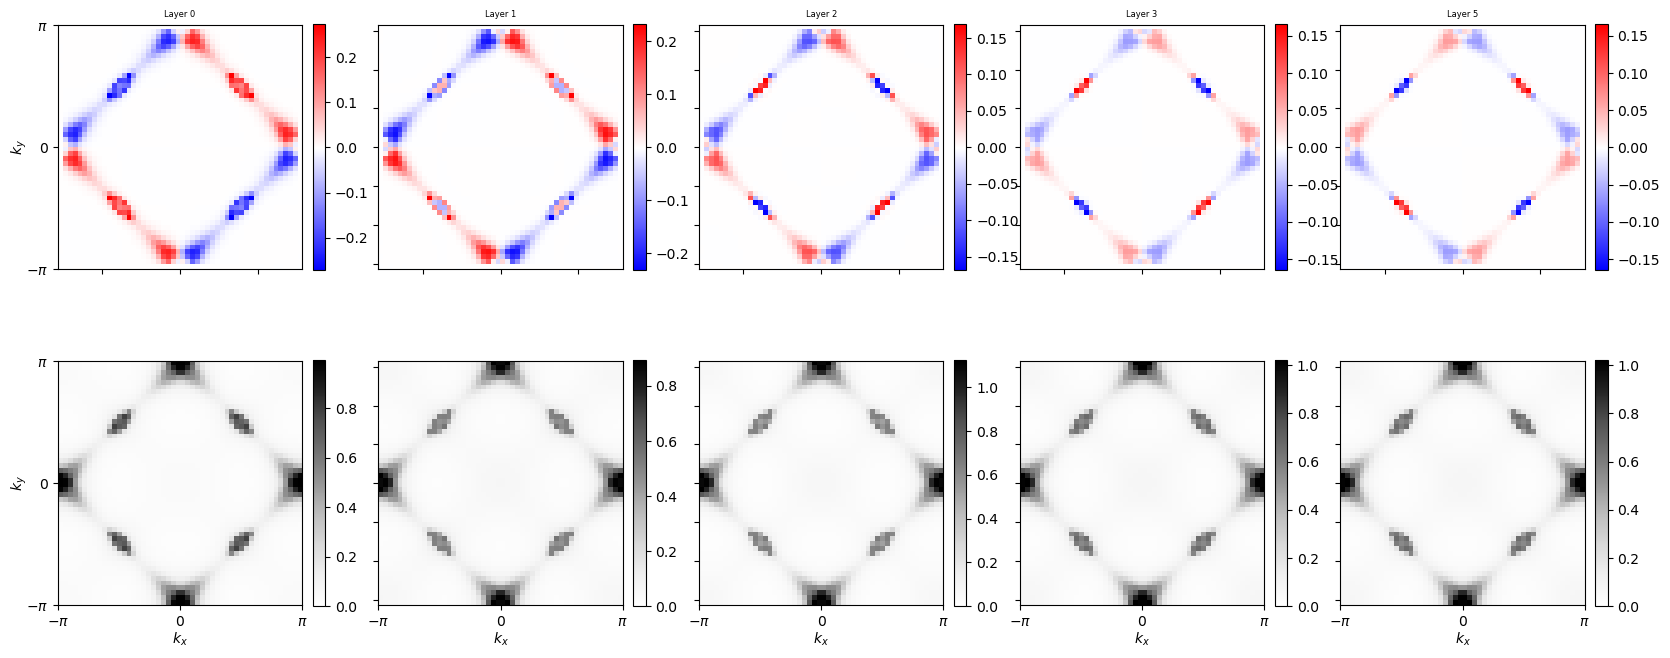

In [104]:
Gamma = 10e-2
len_z = param['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,5,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)


## Checking the spectral density along a 1D path

In [105]:
Lq = 500 #number of k-points in each direction
Gamma = 1.e-3


# Define the k-point grid
kxs = np.linspace(0,pi,Lq)
kys = kxs
#Diagonalize Hamiltonian
es,psis = eigs_H(kxs,kys,Hamiltonian_fct,param)

#compute spectral density
layers = np.arange(0,param['len_z']//2,1,dtype=int)
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

    #computespectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

spin_spec_dens = np.array(spin_spec_dens)
spec_dens = np.array(spec_dens)


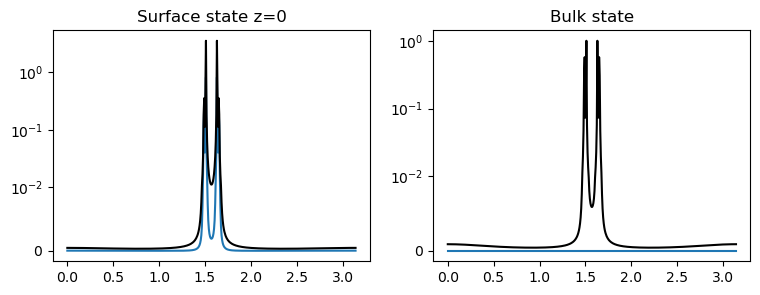

In [108]:
fig,axs = plt.subplots(1,2,figsize=(9,3))

axs[0].set_title('Surface state z=0')
axs[0].plot(kxs,spin_spec_dens[0],'-')
axs[0].plot(kxs,spec_dens[0],'k-')
axs[0].set_yscale('symlog',linthresh=1e-2)

axs[1].set_title('Bulk state')
axs[1].plot(kxs,spin_spec_dens[-1],'-')
axs[1].plot(kxs,spec_dens[-1],'k-')
axs[1].set_yscale('symlog',linthresh=1e-2)

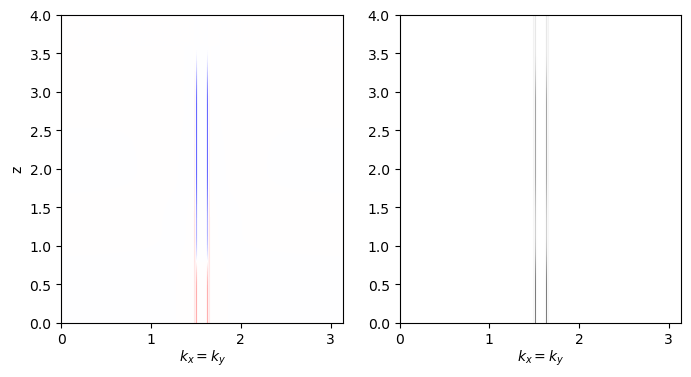

In [109]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))

ax1.set_xlabel('$k_x=k_y$',labelpad=1)
ax2.set_xlabel('$k_x=k_y$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')


In [110]:
#setting parameters
Lq = 40 #number of k-points in each direction


# Calculate spin conductivity
Gamma = 2e-1
kmesh_BZ = sample_reducedBZ(Lq) #you need to work with the right BZ: No translation symmetry breaking -> folded BZ
layer = 0
proj_2layers = np.sum([projector2layer(layer+j,len_z=param['len_z']) for j in range(4)],axis=0)
Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path')
cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=np.kron(proj_2layers,np.ones_like(Spin_operator)),kmesh_BZ=kmesh_BZ,optimize='path')
print('spin_cond: \t', spin_cond)
print('cond: \t', cond)
print('spin splitter angle: \t', 2*np.arctan(spin_cond[0,0]/cond[0,0]) *180/pi)


spin_cond: 	 [[ 1.43814541e-01 -4.86430352e-19]
 [-1.87077812e-19 -1.43814541e-01]]
cond: 	 [[ 7.42329760e-01 -5.73754541e-19]
 [-6.96409599e-19  7.42329760e-01]]
spin splitter angle: 	 21.928630224961438


In [111]:
layers = np.linspace(0,len_z//2,5,dtype=int)
spin_cond00 = []
cond00 = []

for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
    spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path') 
    cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=np.kron(proj_2layers,np.ones(4)),kmesh_BZ=kmesh_BZ,optimize='path')
    spin_cond00.append(spin_cond[0,0])
    cond00.append(cond[0,0])

Text(0, 0.5, 'Conductivity')

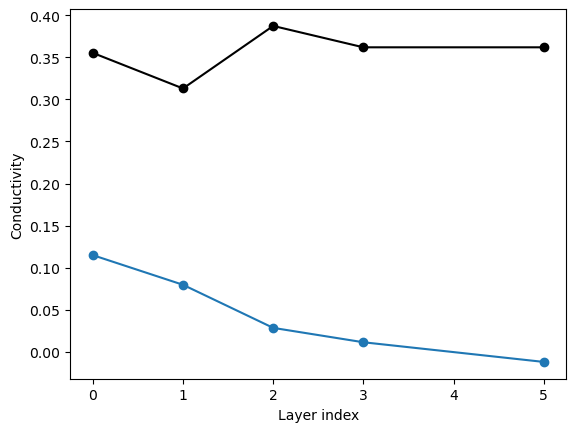

In [112]:
plt.plot(layers,spin_cond00,'o-')
plt.plot(layers,cond00,'ko-')
plt.xlabel('Layer index')
plt.ylabel('Conductivity')